In [5]:

# AI-Based Maintenance: Preprocessing


import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Load your dataset (replace path with your CSV location)
df = pd.read_csv("C:/Users/HP/Downloads/complaints_dataset.csv")
print(df)


    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [7]:
#  Text Cleaning
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['Cleaned_Text'] = df['Complaint_Text'].apply(clean_text)
print(df)

    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [9]:
# Tokenization (simple split)
df['Tokens'] = df['Cleaned_Text'].apply(lambda x: x.split())
print(df)

    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [11]:
# 3️⃣ Stopword Removal (hardcoded list)
stop_words = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours','yourself',
    'yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself',
    'they','them','their','theirs','themselves','what','which','who','whom','this','that',
    'these','those','am','is','are','was','were','be','been','being','have','has','had','having',
    'do','does','did','doing','a','an','the','and','but','if','or','because','as','until','while',
    'of','at','by','for','with','about','against','between','into','through','during','before',
    'after','above','below','to','from','up','down','in','out','on','off','over','under','again',
    'further','then','once','here','there','when','where','why','how','all','any','both','each',
    'few','more','most','other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now'
])
df['Tokens'] = df['Tokens'].apply(lambda tokens: [w for w in tokens if w not in stop_words])
print(df)

    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [13]:
# Simple Lemmatization (rule-based)
def simple_lemmatizer(word):
    if word.endswith('ing'):
        return word[:-3]
    if word.endswith('ed'):
        return word[:-2]
    return word

df['Tokens'] = df['Tokens'].apply(lambda tokens: [simple_lemmatizer(w) for w in tokens])
print(df)

    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [15]:

# Join tokens back to text
df['Processed_Text'] = df['Tokens'].apply(lambda x: ' '.join(x))
print(df)

    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [17]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Processed_Text'])
print(df)


    Block                               Complaint_Text     Category Priority  \
0       B                      Power outage in block B  Electricity     High   
1       C  Frequent water supply disruption in block C   Sanitation     High   
2       B        Unauthorized entry noticed in block B        Water   Medium   
3       D       Elevator breakdown reported in block D        Water     High   
4       B                      Power outage in block B  Electricity   Medium   
..    ...                                          ...          ...      ...   
195     B        Security alarm not working in block B   Sanitation     High   
196     C  Frequent water supply disruption in block C  Electricity      Low   
197     A             Electric wiring issue in block A        Other      Low   
198     D  Frequent water supply disruption in block D        Other   Medium   
199     A                  Lift not working in block A   Sanitation   Medium   

           Date       Status     Feedba

In [19]:
# Export processed dataset to CSV
df.to_csv('complaints_dataset_processed.csv', index=False)
print("Preprocessing complete. Processed CSV saved as 'complaints_dataset_processed.csv'.")
print(df[['Complaint_Text','Processed_Text']].head(10))
print(df)

Preprocessing complete. Processed CSV saved as 'complaints_dataset_processed.csv'.
                                Complaint_Text  \
0                      Power outage in block B   
1  Frequent water supply disruption in block C   
2        Unauthorized entry noticed in block B   
3       Elevator breakdown reported in block D   
4                      Power outage in block B   
5       Elevator breakdown reported in block A   
6                      Power outage in block D   
7        Unauthorized entry noticed in block D   
8       Elevator breakdown reported in block A   
9        Unauthorized entry noticed in block E   

                             Processed_Text  
0                      power outage block b  
1  frequent water supply disruption block c  
2            unauthoriz entry notic block b  
3         elevator breakdown report block d  
4                      power outage block b  
5           elevator breakdown report block  
6                      power outage block d 

In [22]:
# Check for missing values
print("Missing values in dataset:")
print(df.isnull().sum())

# Check duplicate complaints
duplicates = df.duplicated(subset=['Complaint_Text']).sum()
print("Number of duplicate complaints:", duplicates)

# Check empty processed text
empty_text = df[df['Processed_Text'].str.strip() == ""]
print("Empty processed text rows:", len(empty_text))

# Basic dataset info
print("\nDataset Info:")
print(df.info())

print("\nSample Processed Data:")
print(df[['Complaint_Text','Processed_Text']].head())

Missing values in dataset:
Block             0
Complaint_Text    0
Category          0
Priority          0
Date              0
Status            0
Feedback          0
Cleaned_Text      0
Tokens            0
Processed_Text    0
dtype: int64
Number of duplicate complaints: 151
Empty processed text rows: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Block           200 non-null    object
 1   Complaint_Text  200 non-null    object
 2   Category        200 non-null    object
 3   Priority        200 non-null    object
 4   Date            200 non-null    object
 5   Status          200 non-null    object
 6   Feedback        200 non-null    object
 7   Cleaned_Text    200 non-null    object
 8   Tokens          200 non-null    object
 9   Processed_Text  200 non-null    object
dtypes: object(10)
memory usage: 15.8+ KB
None


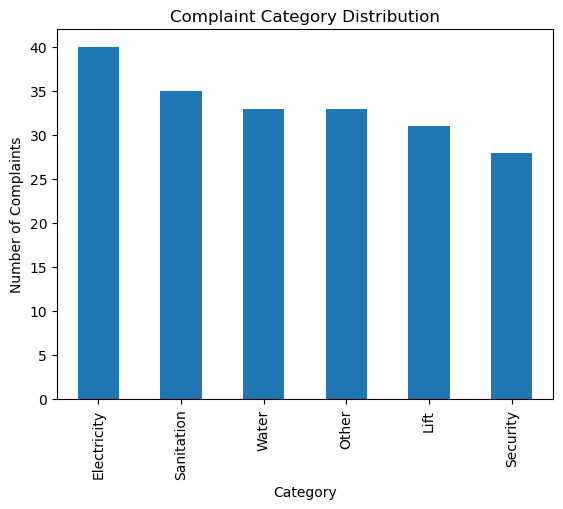

Category
Electricity    40
Sanitation     35
Water          33
Other          33
Lift           31
Security       28
Name: count, dtype: int64


In [24]:
import matplotlib.pyplot as plt

category_counts = df['Category'].value_counts()

plt.figure()
category_counts.plot(kind='bar')
plt.title("Complaint Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.show()

print(category_counts)

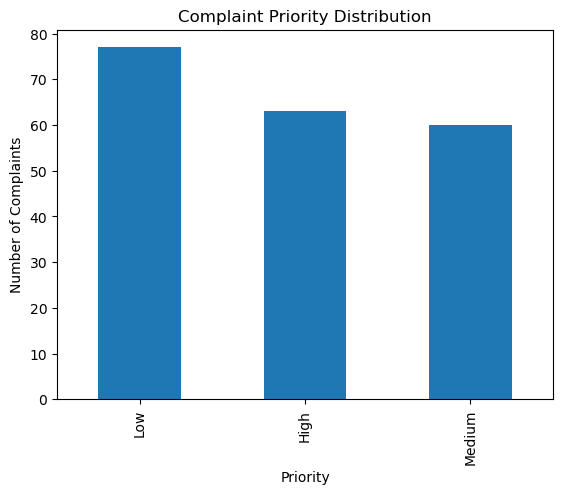

Priority
Low       77
High      63
Medium    60
Name: count, dtype: int64


In [26]:
priority_counts = df['Priority'].value_counts()

plt.figure()
priority_counts.plot(kind='bar')
plt.title("Complaint Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Complaints")
plt.show()

print(priority_counts)

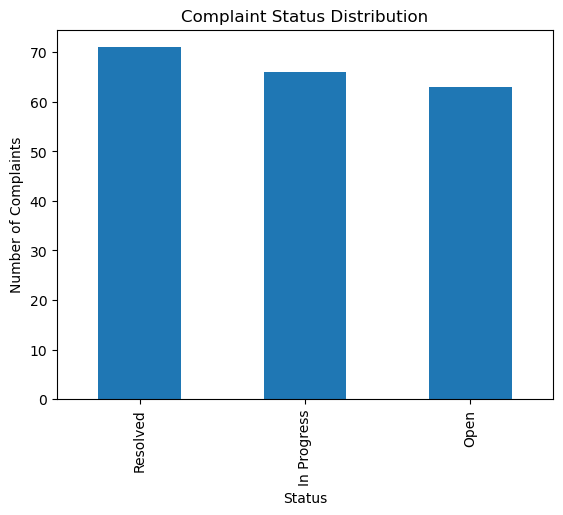

Status
Resolved       71
In Progress    66
Open           63
Name: count, dtype: int64


In [28]:
status_counts = df['Status'].value_counts()

plt.figure()
status_counts.plot(kind='bar')
plt.title("Complaint Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Complaints")
plt.show()

print(status_counts)

In [30]:
from collections import Counter

all_words = []

for tokens in df['Tokens']:
    all_words.extend(tokens)

word_freq = Counter(all_words)

top_keywords = word_freq.most_common(15)

print("Top 15 Frequent Keywords:")
for word, freq in top_keywords:
    print(word, ":", freq)

Top 15 Frequent Keywords:
block : 200
b : 55
work : 44
e : 40
c : 39
d : 39
water : 34
power : 27
outage : 27
security : 25
alarm : 25
electric : 25
wir : 25
issue : 25
elevator : 19


In [32]:
from sklearn.model_selection import train_test_split

# Features = TF-IDF vectors
X = vectorizer.fit_transform(df['Processed_Text'])

# Target label (example: Category)
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (160, 25)
Testing Data Size: (40, 25)


In [34]:
print("Preprocessing Summary")
print("---------------------")

print("Total complaints:", len(df))
print("Unique complaint categories:", df['Category'].nunique())
print("Duplicate complaints:", duplicates)
print("Top keywords:", top_keywords)

print("\nSample Processed Text:")
print(df[['Complaint_Text','Processed_Text']].head(10))

Preprocessing Summary
---------------------
Total complaints: 200
Unique complaint categories: 6
Duplicate complaints: 151
Top keywords: [('block', 200), ('b', 55), ('work', 44), ('e', 40), ('c', 39), ('d', 39), ('water', 34), ('power', 27), ('outage', 27), ('security', 25), ('alarm', 25), ('electric', 25), ('wir', 25), ('issue', 25), ('elevator', 19)]

Sample Processed Text:
                                Complaint_Text  \
0                      Power outage in block B   
1  Frequent water supply disruption in block C   
2        Unauthorized entry noticed in block B   
3       Elevator breakdown reported in block D   
4                      Power outage in block B   
5       Elevator breakdown reported in block A   
6                      Power outage in block D   
7        Unauthorized entry noticed in block D   
8       Elevator breakdown reported in block A   
9        Unauthorized entry noticed in block E   

                             Processed_Text  
0                      p

In [36]:
df.to_csv("complaints_dataset_final_processed.csv", index=False)
print("Final processed dataset saved successfully.")

Final processed dataset saved successfully.


In [38]:
import os
print(os.getcwd())

C:\Users\HP
